# Notebook 07 — Comparative Evaluation

This notebook compares all centralized baseline models with the
privacy-preserving Federated Neural Network using the same CICIDS2017 test set.

In [5]:
# ============================================================
# IMPORT LIBRARIES AND LOAD FEDERATED RESULTS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FEDERATED_RESULTS_PATH = Path(
    "../results/federated_learning_results.csv"
)

assert FEDERATED_RESULTS_PATH.exists(), (
    f"Federated results file not found: "
    f"{FEDERATED_RESULTS_PATH.resolve()}"
)

federated_results = pd.read_csv(
    FEDERATED_RESULTS_PATH
)

print("✅ Federated results loaded successfully.")
federated_results

✅ Federated results loaded successfully.


,Model,Training Approach,Clients,Rounds,Local Epochs,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Federated Neural Network (FedAvg),Federated Learning,4,10,2,0.959318,0.985658,0.959318,0.970626,0.938771,0.568357,0.938771


In [6]:
# ============================================================
# DEFINE THE METRICS USED FOR ALL MODEL COMPARISONS
# ============================================================

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy",
]

missing_metrics = [
    metric
    for metric in metric_columns
    if metric not in federated_results.columns
]

assert not missing_metrics, (
    f"Missing federated metrics: {missing_metrics}. "
    "Run the updated Step 16 in Notebook 06."
)

print("✅ All required federated metrics are available.")
print("Metrics compared:", metric_columns)

✅ All required federated metrics are available.
Metrics compared: ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Macro Recall', 'Macro F1', 'Balanced Accuracy']


In [8]:
# ============================================================
# CENTRALIZED RESULTS FROM NOTEBOOK 05
# Values are taken from the final Experiment 2 results table.
# ============================================================

baseline_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
            "XGBoost",
        ],
        "Training Approach": [
            "Centralized",
            "Centralized",
            "Centralized",
            "Centralized",
        ],
        "Accuracy": [95.99, 99.82, 99.86, 99.87],
        "Precision": [96.80, 99.84, 99.86, 99.88],
        "Recall": [95.99, 99.82, 99.86, 99.87],
        "F1 Score": [96.13, 99.83, 99.86, 99.87],
        "Macro Recall": [66.69, 90.65, 84.73, 90.63],
        "Macro F1": [61.53, 84.55, 85.65, 89.37],
        "Balanced Accuracy": [66.69, 90.65, 84.73, 90.63],
    }
)

# Convert percentage values into decimals for calculations.
baseline_results[metric_columns] = (
    baseline_results[metric_columns] / 100
)

print("✅ Centralized baseline results loaded.")
baseline_results

✅ Centralized baseline results loaded.


,Model,Training Approach,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Logistic Regression,Centralized,0.9599,0.9680,0.9599,0.9613,0.6669,0.6153,0.6669
1,Decision Tree,Centralized,0.9982,0.9984,0.9982,0.9983,0.9065,0.8455,0.9065
2,Random Forest,Centralized,0.9986,0.9986,0.9986,0.9986,0.8473,0.8565,0.8473
3,XGBoost,Centralized,0.9987,0.9988,0.9987,0.9987,0.9063,0.8937,0.9063


In [9]:
# ============================================================
# COMBINE CENTRALIZED AND FEDERATED MODEL RESULTS
# ============================================================

federated_comparison = federated_results[
    ["Model", "Training Approach"] + metric_columns
].copy()

comparison_df = pd.concat(
    [
        baseline_results,
        federated_comparison,
    ],
    ignore_index=True,
)

# Create a percentage-format table for clear display.
display_comparison_df = comparison_df.copy()

for metric in metric_columns:
    display_comparison_df[metric] = (
        display_comparison_df[metric] * 100
    ).round(2)

print("✅ Complete comparison table created.")
display_comparison_df

✅ Complete comparison table created.


,Model,Training Approach,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Logistic Regression,Centralized,95.99,96.80,95.99,96.13,66.69,61.53,66.69
1,Decision Tree,Centralized,99.82,99.84,99.82,99.83,90.65,84.55,90.65
2,Random Forest,Centralized,99.86,99.86,99.86,99.86,84.73,85.65,84.73
3,XGBoost,Centralized,99.87,99.88,99.87,99.87,90.63,89.37,90.63
4,Federated Neural Network (FedAvg),Federated Learning,95.93,98.57,95.93,97.06,93.88,56.84,93.88


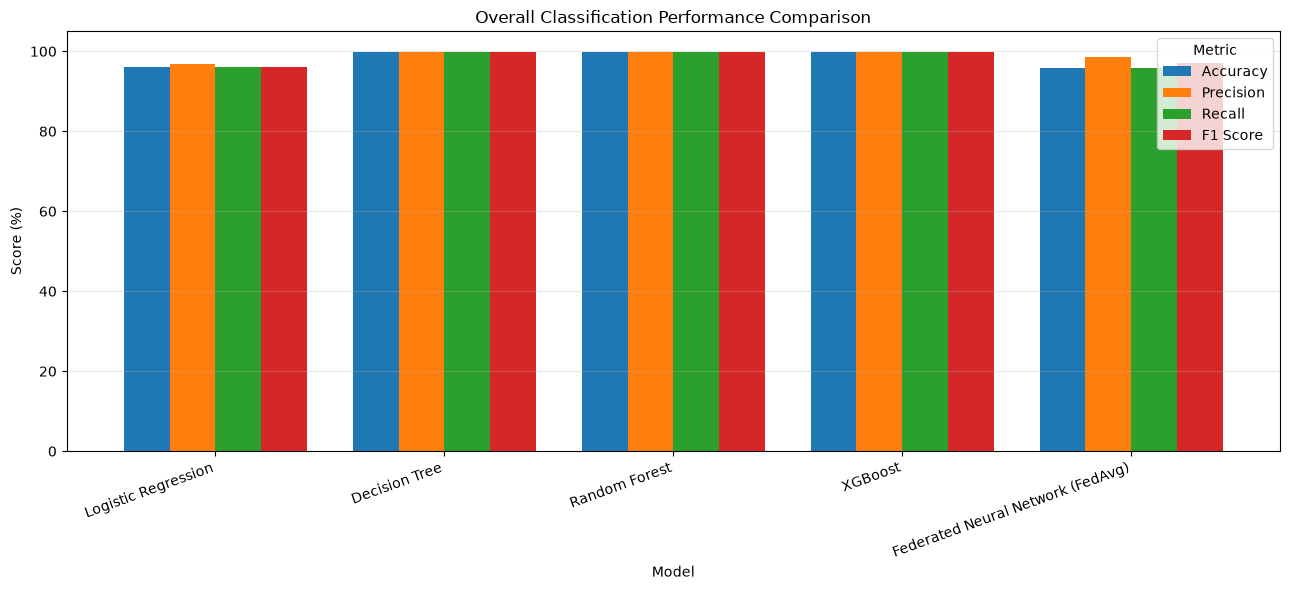

✅ Overall metrics chart created.


In [13]:
# ============================================================
# PLOT OVERALL CLASSIFICATION PERFORMANCE METRICS
# ============================================================

overall_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
]

overall_plot_data = (
    comparison_df
    .set_index("Model")[overall_metrics]
    .multiply(100)
)

ax = overall_plot_data.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8,
)

plt.title("Overall Classification Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 105)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

print("✅ Overall metrics chart created.")

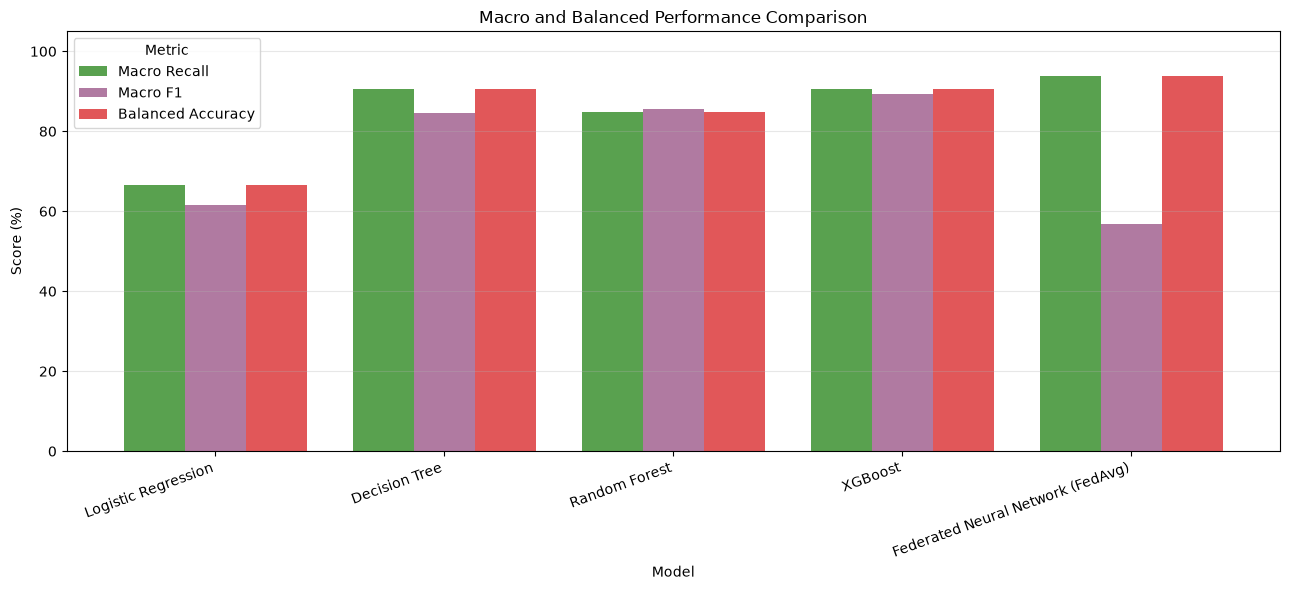

✅ Macro and balanced metrics chart created.


In [12]:
# ============================================================
# PLOT METRICS THAT GIVE EQUAL IMPORTANCE TO EVERY CLASS
# ============================================================

balanced_metrics = [
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy",
]

balanced_plot_data = (
    comparison_df
    .set_index("Model")[balanced_metrics]
    .multiply(100)
)

ax = balanced_plot_data.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8,
    color=["#59A14F", "#B07AA1", "#E15759"],
)

plt.title("Macro and Balanced Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 105)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

print("✅ Macro and balanced metrics chart created.")

In [14]:
# ============================================================
# COMPARE THE BEST CENTRALIZED MODEL WITH FEDAVG
# ============================================================

xgboost_metrics = comparison_df.loc[
    comparison_df["Model"] == "XGBoost",
    metric_columns,
].iloc[0]

federated_metrics = comparison_df.loc[
    comparison_df["Training Approach"] == "Federated Learning",
    metric_columns,
].iloc[0]

tradeoff_df = pd.DataFrame(
    {
        "Metric": metric_columns,
        "Centralized XGBoost (%)": (
            xgboost_metrics.values * 100
        ).round(2),
        "Federated FedAvg (%)": (
            federated_metrics.values * 100
        ).round(2),
        "Difference (percentage points)": (
            (xgboost_metrics.values - federated_metrics.values) * 100
        ).round(2),
    }
)

print("✅ XGBoost vs Federated Learning comparison created.")
tradeoff_df

✅ XGBoost vs Federated Learning comparison created.


,Metric,Centralized XGBoost (%),Federated FedAvg (%),Difference (percentage points)
0,Accuracy,99.87,95.93,3.94
1,Precision,99.88,98.57,1.31
2,Recall,99.87,95.93,3.94
3,F1 Score,99.87,97.06,2.81
4,Macro Recall,90.63,93.88,-3.25
5,Macro F1,89.37,56.84,32.53
6,Balanced Accuracy,90.63,93.88,-3.25


In [15]:
# ============================================================
# IDENTIFY THE HIGHEST-SCORING MODEL FOR EACH METRIC
# ============================================================

best_models = []

for metric in metric_columns:
    best_index = comparison_df[metric].idxmax()

    best_models.append(
        {
            "Metric": metric,
            "Best Model": comparison_df.loc[
                best_index,
                "Model",
            ],
            "Best Score (%)": round(
                comparison_df.loc[
                    best_index,
                    metric,
                ] * 100,
                2,
            ),
        }
    )

best_models_df = pd.DataFrame(best_models)

print("✅ Best model for each metric identified.")
best_models_df

✅ Best model for each metric identified.


,Metric,Best Model,Best Score (%)
0,Accuracy,XGBoost,99.87
1,Precision,XGBoost,99.88
2,Recall,XGBoost,99.87
3,F1 Score,XGBoost,99.87
4,Macro Recall,Federated Neural Network (FedAvg),93.88
5,Macro F1,XGBoost,89.37
6,Balanced Accuracy,Federated Neural Network (FedAvg),93.88


In [16]:
# ============================================================
# PRINT FINAL EVALUATION SUMMARY
# ============================================================

federated_row = comparison_df.loc[
    comparison_df["Training Approach"] == "Federated Learning"
].iloc[0]

xgboost_row = comparison_df.loc[
    comparison_df["Model"] == "XGBoost"
].iloc[0]

accuracy_gap = (
    xgboost_row["Accuracy"]
    - federated_row["Accuracy"]
) * 100

macro_f1_gap = (
    xgboost_row["Macro F1"]
    - federated_row["Macro F1"]
) * 100

print("FINAL COMPARATIVE EVALUATION")
print("=" * 60)

print(
    f"Best centralized accuracy: "
    f"{xgboost_row['Accuracy']:.2%} (XGBoost)"
)

print(
    f"Federated FedAvg accuracy: "
    f"{federated_row['Accuracy']:.2%}"
)

print(
    f"Accuracy trade-off: "
    f"{accuracy_gap:.2f} percentage points"
)

print(
    f"Macro F1 trade-off: "
    f"{macro_f1_gap:.2f} percentage points"
)

print("\nConclusion:")
print(
    "Centralized models achieve the strongest predictive scores. "
    "The Federated Neural Network provides a privacy-preserving "
    "alternative by aggregating model updates instead of sharing "
    "raw network-traffic records."
)

FINAL COMPARATIVE EVALUATION
Best centralized accuracy: 99.87% (XGBoost)
Federated FedAvg accuracy: 95.93%
Accuracy trade-off: 3.94 percentage points
Macro F1 trade-off: 32.53 percentage points

Conclusion:
Centralized models achieve the strongest predictive scores. The Federated Neural Network provides a privacy-preserving alternative by aggregating model updates instead of sharing raw network-traffic records.


In [18]:
# ============================================================
# SAVE COMPARISON TABLES FOR THE FINAL REPORT AND DASHBOARD
# ============================================================

RESULTS_DIRECTORY = Path("../results")

COMPARISON_PATH = RESULTS_DIRECTORY / (
    "centralized_vs_federated_comparison.csv"
)

TRADEOFF_PATH = RESULTS_DIRECTORY / (
    "xgboost_vs_federated_tradeoff.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
)

tradeoff_df.to_csv(
    TRADEOFF_PATH,
    index=False,
)

print("✅ Comparative evaluation files saved.")
print("Comparison table:", COMPARISON_PATH.resolve())
print("Trade-off table:", TRADEOFF_PATH.resolve())

✅ Comparative evaluation files saved.
Comparison table: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\centralized_vs_federated_comparison.csv
Trade-off table: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\xgboost_vs_federated_tradeoff.csv
